In [1]:
import pandas as pd

def midsquare(seed: int, n: int = 100):
    seed_str = str(seed)
    d = len(seed_str)
    x = seed

    data = []
    for i in range(1, n + 1):
        sq = x**2
        sq_str = str(sq).zfill(2 * d)
        start = (len(sq_str) - d) // 2
        x = int(sq_str[start : start + d])
        u = x / (10**d)
        data.append({"i": i, "X_i": x, "u_i": u})

    return pd.DataFrame(data), d

# Ejecución para las semillas del ejercicio
seeds = [1931, 675248, 4567, 12122, 7179345]
results = {}

for s in seeds:
    df, d = midsquare(s, n=100)
    results[s] = df
    print(f"== Semilla {s} (D={d}) ==")
    print(df.head(100).to_string(index=False))
    print("\n")

== Semilla 1931 (D=4) ==
  i  X_i    u_i
  1 7287 0.7287
  2 1003 0.1003
  3   60 0.0060
  4   36 0.0036
  5   12 0.0012
  6    1 0.0001
  7    0 0.0000
  8    0 0.0000
  9    0 0.0000
 10    0 0.0000
 11    0 0.0000
 12    0 0.0000
 13    0 0.0000
 14    0 0.0000
 15    0 0.0000
 16    0 0.0000
 17    0 0.0000
 18    0 0.0000
 19    0 0.0000
 20    0 0.0000
 21    0 0.0000
 22    0 0.0000
 23    0 0.0000
 24    0 0.0000
 25    0 0.0000
 26    0 0.0000
 27    0 0.0000
 28    0 0.0000
 29    0 0.0000
 30    0 0.0000
 31    0 0.0000
 32    0 0.0000
 33    0 0.0000
 34    0 0.0000
 35    0 0.0000
 36    0 0.0000
 37    0 0.0000
 38    0 0.0000
 39    0 0.0000
 40    0 0.0000
 41    0 0.0000
 42    0 0.0000
 43    0 0.0000
 44    0 0.0000
 45    0 0.0000
 46    0 0.0000
 47    0 0.0000
 48    0 0.0000
 49    0 0.0000
 50    0 0.0000
 51    0 0.0000
 52    0 0.0000
 53    0 0.0000
 54    0 0.0000
 55    0 0.0000
 56    0 0.0000
 57    0 0.0000
 58    0 0.0000
 59    0 0.0000
 60    0 0.0000

5.1.2 MÉTODO CONGRUENCIAL MIXTO

---


Semilla: a) X0 = 127, a = 115, c = 0, m = 128

In [2]:
import numpy as np
import time
from datetime import datetime

def genran(a,c,m,xant):
    xsig = (a*xant + c) % m
    usig = xsig / m
    return [xsig,usig]

def genranN(a,c,m,x0,N):
    xant = x0
    I=[]
    X=[]
    U=[]
    for t in range(1, N+1):
        [xi,ui] = genran(a,c,m,xant)
        I.append(t)
        X.append(xi)
        U.append(ui)
        xant = xi
    return [I,X,U]

def showValues(I,X,U):
    print("i\tXi\tUi")
    for t in range(0, len(X)):
        print("%d\t%d\t%2.4f" % (I[t],X[t],U[t]), sep=' ', end='\n')

In [3]:
N = 100

a = 115.0
c = 0
m = 128
x0 = 127.0

[I,X,U] = genranN(a,c,m,x0,N)
showValues(I,X,U)

i	Xi	Ui
1	13	0.1016
2	87	0.6797
3	21	0.1641
4	111	0.8672
5	93	0.7266
6	71	0.5547
7	101	0.7891
8	95	0.7422
9	45	0.3516
10	55	0.4297
11	53	0.4141
12	79	0.6172
13	125	0.9766
14	39	0.3047
15	5	0.0391
16	63	0.4922
17	77	0.6016
18	23	0.1797
19	85	0.6641
20	47	0.3672
21	29	0.2266
22	7	0.0547
23	37	0.2891
24	31	0.2422
25	109	0.8516
26	119	0.9297
27	117	0.9141
28	15	0.1172
29	61	0.4766
30	103	0.8047
31	69	0.5391
32	127	0.9922
33	13	0.1016
34	87	0.6797
35	21	0.1641
36	111	0.8672
37	93	0.7266
38	71	0.5547
39	101	0.7891
40	95	0.7422
41	45	0.3516
42	55	0.4297
43	53	0.4141
44	79	0.6172
45	125	0.9766
46	39	0.3047
47	5	0.0391
48	63	0.4922
49	77	0.6016
50	23	0.1797
51	85	0.6641
52	47	0.3672
53	29	0.2266
54	7	0.0547
55	37	0.2891
56	31	0.2422
57	109	0.8516
58	119	0.9297
59	117	0.9141
60	15	0.1172
61	61	0.4766
62	103	0.8047
63	69	0.5391
64	127	0.9922
65	13	0.1016
66	87	0.6797
67	21	0.1641
68	111	0.8672
69	93	0.7266
70	71	0.5547
71	101	0.7891
72	95	0.7422
73	45	0.3516
74	55	0.4297
75	53	0.4141
76	79	0.6172

semilla: b) X0 = 43, a = 25, c = 5, m = 48

In [4]:
N = 100

a = 25.0
c = 5
m = 48
x0 = 43.0

[I,X,U] = genranN(a,c,m,x0,N)
showValues(I,X,U)

i	Xi	Ui
1	24	0.5000
2	29	0.6042
3	10	0.2083
4	15	0.3125
5	44	0.9167
6	1	0.0208
7	30	0.6250
8	35	0.7292
9	16	0.3333
10	21	0.4375
11	2	0.0417
12	7	0.1458
13	36	0.7500
14	41	0.8542
15	22	0.4583
16	27	0.5625
17	8	0.1667
18	13	0.2708
19	42	0.8750
20	47	0.9792
21	28	0.5833
22	33	0.6875
23	14	0.2917
24	19	0.3958
25	0	0.0000
26	5	0.1042
27	34	0.7083
28	39	0.8125
29	20	0.4167
30	25	0.5208
31	6	0.1250
32	11	0.2292
33	40	0.8333
34	45	0.9375
35	26	0.5417
36	31	0.6458
37	12	0.2500
38	17	0.3542
39	46	0.9583
40	3	0.0625
41	32	0.6667
42	37	0.7708
43	18	0.3750
44	23	0.4792
45	4	0.0833
46	9	0.1875
47	38	0.7917
48	43	0.8958
49	24	0.5000
50	29	0.6042
51	10	0.2083
52	15	0.3125
53	44	0.9167
54	1	0.0208
55	30	0.6250
56	35	0.7292
57	16	0.3333
58	21	0.4375
59	2	0.0417
60	7	0.1458
61	36	0.7500
62	41	0.8542
63	22	0.4583
64	27	0.5625
65	8	0.1667
66	13	0.2708
67	42	0.8750
68	47	0.9792
69	28	0.5833
70	33	0.6875
71	14	0.2917
72	19	0.3958
73	0	0.0000
74	5	0.1042
75	34	0.7083
76	39	0.8125
77	20	0.4167
78	25	0.5208
79	

semilla: c) X0 = 13, a = 16807, c = 0, m = 2**31 – 1

In [5]:
N = 100

a = 16807.0
c = 0
m = 2**31-1
x0 = 13.0

[I,X,U] = genranN(a,c,m,x0,N)
showValues(I,X,U)

i	Xi	Ui
1	218491	0.0001
2	1524694590	0.7100
3	1767098126	0.8229
4	2066849319	0.9625
5	1988514208	0.9260
6	1817779242	0.8465
7	1313358072	0.6116
8	1772192238	0.8252
9	1784243823	0.8309
10	324286453	0.1510
11	2116403132	0.9855
12	1615794263	0.7524
13	1723461926	0.8025
14	965159546	0.4494
15	1492503831	0.6950
16	1902890657	0.8861
17	1556801075	0.7249
18	214912477	0.1001
19	2113990332	0.9844
20	1866053956	0.8689
21	917657704	0.4273
22	1992962021	0.9280
23	1410244688	0.6567
24	205459277	0.0957
25	364163	0.0002
26	1825520247	0.8501
27	419926640	0.1955
28	1075774438	0.5009
29	876155373	0.4080
30	247986532	0.1155
31	1791368144	0.8342
32	1951148915	0.9086
33	884524715	0.4119
34	1325080471	0.6170
35	1222056707	0.5691
36	573474641	0.2670
37	481683551	0.2243
38	1789576114	0.8333
39	1897271763	0.8835
40	1609330085	0.7494
41	454204630	0.2115
42	1660334972	0.7732
43	847365286	0.3946
44	1704298545	0.7936
45	1008762129	0.4697
46	2029192685	0.9449
47	453658788	0.2113
48	1076303066	0.5012
49	1170871581	0

Semilla: d) X0 = 29022024, a = 25214903917, c = 11, m = 2**48

In [6]:
N = 100

a = 25214903917
c = 11
m = 2**48
x0 = 29022024

[I,X,U] = genranN(a,c,m,x0,N)
showValues(I,X,U)

i	Xi	Ui
1	234082165873075	0.8316
2	148167533855554	0.5264
3	141807657398053	0.5038
4	3454754934988	0.0123
5	256501397597927	0.9113
6	264449157726822	0.9395
7	11136630401401	0.0396
8	67913613467280	0.2413
9	262619324982107	0.9330
10	188429820514250	0.6694
11	145639627126029	0.5174
12	85824273155220	0.3049
13	167175878175503	0.5939
14	245552656813934	0.8724
15	79047489316321	0.2808
16	196794407487192	0.6992
17	106220417415683	0.3774
18	10128563217746	0.0360
19	31476005146613	0.1118
20	217709941352796	0.7735
21	152714571351095	0.5426
22	99936443708790	0.3550
23	56972566644553	0.2024
24	165707797262368	0.5887
25	48478755519915	0.1722
26	232957411402714	0.8276
27	165084121407453	0.5865
28	19900186500900	0.0707
29	198494058158687	0.7052
30	269746417046654	0.9583
31	210655086898609	0.7484
32	272644017568360	0.9686
33	12082421386835	0.0429
34	127841417489250	0.4542
35	68007552632005	0.2416
36	177087830181356	0.6291
37	183362832420231	0.6514
38	115833433738374	0.4115
39	146529460320537	0.5206
4

Semilla: e) X0 = 3, a = 5, c = 7, m = 200


In [7]:
N = 100

a = 5
c = 7
m = 200
x0 = 3

[I,X,U] = genranN(a,c,m,x0,N)
showValues(I,X,U)

i	Xi	Ui
1	22	0.1100
2	117	0.5850
3	192	0.9600
4	167	0.8350
5	42	0.2100
6	17	0.0850
7	92	0.4600
8	67	0.3350
9	142	0.7100
10	117	0.5850
11	192	0.9600
12	167	0.8350
13	42	0.2100
14	17	0.0850
15	92	0.4600
16	67	0.3350
17	142	0.7100
18	117	0.5850
19	192	0.9600
20	167	0.8350
21	42	0.2100
22	17	0.0850
23	92	0.4600
24	67	0.3350
25	142	0.7100
26	117	0.5850
27	192	0.9600
28	167	0.8350
29	42	0.2100
30	17	0.0850
31	92	0.4600
32	67	0.3350
33	142	0.7100
34	117	0.5850
35	192	0.9600
36	167	0.8350
37	42	0.2100
38	17	0.0850
39	92	0.4600
40	67	0.3350
41	142	0.7100
42	117	0.5850
43	192	0.9600
44	167	0.8350
45	42	0.2100
46	17	0.0850
47	92	0.4600
48	67	0.3350
49	142	0.7100
50	117	0.5850
51	192	0.9600
52	167	0.8350
53	42	0.2100
54	17	0.0850
55	92	0.4600
56	67	0.3350
57	142	0.7100
58	117	0.5850
59	192	0.9600
60	167	0.8350
61	42	0.2100
62	17	0.0850
63	92	0.4600
64	67	0.3350
65	142	0.7100
66	117	0.5850
67	192	0.9600
68	167	0.8350
69	42	0.2100
70	17	0.0850
71	92	0.4600
72	67	0.3350
73	142	0.7100
74	117	0.5850
75

5.1.3 Otros Generadores de Números Aleatorios

Los que escogí: a) Generador Shift:Register

In [8]:
def shift_register_generator(n=100, k=7, w=8, seed=[1, 0, 1, 1, 0, 0, 1]):
    bits = list(seed)
    u_sequence = []

    # Generar bits necesarios
    while len(bits) < (n * w) + k:
        next_bit = (bits[-k] + bits[-1]) % 2
        bits.append(next_bit)

    # Agrupar bits en enteros de w bits y normalizar
    for i in range(n):
        byte = bits[i * w : (i + 1) * w]
        val = sum(b << (w - 1 - j) for j, b in enumerate(byte))
        u_sequence.append(round(val / (2**w), 4))

    return u_sequence

# Ejecutar y mostrar enumerados
u_shift = shift_register_generator(100)

print("Generador Shift-Register:")
for idx, val in enumerate(u_shift, start=1):
    print(f"u_{idx} = {val}")

Generador Shift-Register:
u_1 = 0.6953
u_2 = 0.2773
u_3 = 0.043
u_4 = 0.8945
u_5 = 0.4492
u_6 = 0.2656
u_7 = 0.9414
u_8 = 0.2617
u_9 = 0.0156
u_10 = 0.0586
u_11 = 0.9141
u_12 = 0.5977
u_13 = 0.8633
u_14 = 0.1719
u_15 = 0.4336
u_16 = 0.418
u_17 = 0.3906
u_18 = 0.5547
u_19 = 0.0898
u_20 = 0.7891
u_21 = 0.8984
u_22 = 0.5352
u_23 = 0.8828
u_24 = 0.5234
u_25 = 0.0312
u_26 = 0.1211
u_27 = 0.832
u_28 = 0.1992
u_29 = 0.7266
u_30 = 0.3438
u_31 = 0.8672
u_32 = 0.8359
u_33 = 0.7852
u_34 = 0.1094
u_35 = 0.1836
u_36 = 0.582
u_37 = 0.8008
u_38 = 0.0742
u_39 = 0.7695
u_40 = 0.0469
u_41 = 0.0625
u_42 = 0.2461
u_43 = 0.6641
u_44 = 0.4023
u_45 = 0.4531
u_46 = 0.6914
u_47 = 0.7383
u_48 = 0.6758
u_49 = 0.5703
u_50 = 0.2188
u_51 = 0.3711
u_52 = 0.168
u_53 = 0.6016
u_54 = 0.1523
u_55 = 0.5391
u_56 = 0.0938
u_57 = 0.125
u_58 = 0.4961
u_59 = 0.3281
u_60 = 0.8047
u_61 = 0.9102
u_62 = 0.3867
u_63 = 0.4805
u_64 = 0.3555
u_65 = 0.1406
u_66 = 0.4375
u_67 = 0.7422
u_68 = 0.3398
u_69 = 0.2031
u_70 = 0.3086
u_71 = 0.

B) Generador de Congruencia Inversa:

In [9]:
def mod_inverse(x, m):
    if x == 0:
        return 0
    return pow(x, -1, m)

def inversive_congruential_generator(n=100, m=101, a=2, b=7, x0=0):
    u_sequence = []
    x_curr = x0
    for _ in range(n):
        x_inv = mod_inverse(x_curr, m)
        x_next = (a * x_inv + b) % m
        u_sequence.append(round(x_next / m, 4))
        x_curr = x_next
    return u_sequence

# Ejecutar y mostrar enumerados
u_inversive = inversive_congruential_generator(100)

print("Generador de Congruencia Inversa:")
for idx, val in enumerate(u_inversive, start=1):
    print(f"u_{idx} = {val}")

Generador de Congruencia Inversa:
u_1 = 0.0693
u_2 = 0.6436
u_3 = 0.3465
u_4 = 0.5842
u_5 = 0.3069
u_6 = 0.8119
u_7 = 0.7525
u_8 = 0.1485
u_9 = 0.604
u_10 = 0.1188
u_11 = 0.2376
u_12 = 0.6535
u_13 = 0.5545
u_14 = 0.8911
u_15 = 0.1584
u_16 = 0.4455
u_17 = 0.2475
u_18 = 0.9901
u_19 = 0.0495
u_20 = 0.6733
u_21 = 0.099
u_22 = 0.8713
u_23 = 0.6832
u_24 = 0.8812
u_25 = 0.901
u_26 = 0.2673
u_27 = 0.3663
u_28 = 0.4752
u_29 = 0.8614
u_30 = 0.7822
u_31 = 0.6139
u_32 = 0.9406
u_33 = 0.7327
u_34 = 0.7723
u_35 = 0.6337
u_36 = 0.6634
u_37 = 0.0099
u_38 = 0.0891
u_39 = 0.9604
u_40 = 0.5644
u_41 = 0.8416
u_42 = 0.6931
u_43 = 0.3267
u_44 = 0.0396
u_45 = 0.5743
u_46 = 0.1386
u_47 = 0.3564
u_48 = 0.7921
u_49 = 0.5446
u_50 = 0.8515
u_51 = 0.5347
u_52 = 0.2178
u_53 = 0.5248
u_54 = 0.2772
u_55 = 0.7129
u_56 = 0.9307
u_57 = 0.495
u_58 = 0.0297
u_59 = 0.7426
u_60 = 0.3762
u_61 = 0.2277
u_62 = 0.505
u_63 = 0.1089
u_64 = 0.9802
u_65 = 0.0594
u_66 = 0.4059
u_67 = 0.4356
u_68 = 0.297
u_69 = 0.3366
u_70 = 0.1287
u

# 5.1.4 Tamaño de ciclo, pruebas de uniformidad y aleatoriedad

En esta sección se calcula, para **cada una de las 12 secuencias** de números pseudoaleatorios
generadas en los puntos 5.1.1 (MidSquare), 5.1.2 (Congruencial mixto) y 5.1.3 (Otros generadores):

**a.** El **tamaño de ciclo o periodo** de la secuencia.

**b.** La **prueba de uniformidad**, usando el **contraste de Kolmogorov–Smirnov** como prueba principal
y el **contraste $\chi^2$** como verificación complementaria (ambos vistos en clase en las diapositivas
*Test o contrastes para números aleatorios*).

**c.** La **prueba de aleatoriedad**, usando el **Test de Rachas**, que es el método de aleatoriedad
visto en clase.

Todas las pruebas se realizan con un nivel de significancia $\alpha = 0.05$ y $n = 100$.

## Fundamento teórico de las pruebas aplicadas



## Librerías y dependencias

In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

N = 100        # tamaño de las secuencias
ALPHA = 0.05   # nivel de significancia

## Reconstrucción de las 12 secuencias de los puntos 5.1.1, 5.1.2 y 5.1.3

Se reutilizan los mismos generadores implementados anteriormente, devolviendo además la sucesión de
**estados** $X_i$, que es la que se necesita para determinar el periodo.

In [20]:
# ---------- 5.1.1 MidSquare ----------
def midsquare_states(seed, n=N):
    d = len(str(seed))
    x, X, U = seed, [], []
    for _ in range(n):
        sq_str = str(x * x).zfill(2 * d)
        start = (len(sq_str) - d) // 2
        x = int(sq_str[start:start + d])
        X.append(x)
        U.append(x / (10 ** d))
    return X, U, d

# ---------- 5.1.2 Congruencial mixto ----------
def lcg_states(a, c, m, x0, n=N):
    x, X, U = x0, [], []
    for _ in range(n):
        x = (a * x + c) % m
        X.append(x)
        U.append(x / m)
    return X, U

# ---------- 5.1.3 a) Shift-Register ----------
def shift_register(n=N, k=7, w=8, seed=[1, 0, 1, 1, 0, 0, 1]):
    bits, U = list(seed), []
    while len(bits) < (n * w) + k:
        bits.append((bits[-k] + bits[-1]) % 2)
    for i in range(n):
        byte = bits[i * w:(i + 1) * w]
        U.append(round(sum(b << (w - 1 - j) for j, b in enumerate(byte)) / (2 ** w), 4))
    return U

# ---------- 5.1.3 b) Congruencia Inversa ----------
def inversive_states(n=N, m=101, a=2, b=7, x0=0):
    x, X, U = x0, [], []
    for _ in range(n):
        xi = 0 if x == 0 else pow(x, -1, m)
        x = (a * xi + b) % m
        X.append(x)
        U.append(x / m)
    return X, U

print("Generadores definidos correctamente.")

Generadores definidos correctamente.


## a. Tamaño de ciclo o periodo

Se recorre la sucesión de estados guardando la primera aparición de cada uno. Al detectar un estado
repetido se obtienen la cola $\mu$ y el periodo $\lambda$.

In [22]:
def periodo_por_estado(siguiente, x0, limite=2_000_000):
    """Detecta (mu, lambda) recorriendo los estados del generador.
       mu     = longitud de la cola (transitorio)
       lambda = tamaño del ciclo (periodo)"""
    visto = {x0: 0}
    x = x0
    for i in range(1, limite + 1):
        x = siguiente(x)
        if x in visto:
            return visto[x], i - visto[x]
        visto[x] = i
    return None, None          # no se repitió dentro del límite explorado


def periodo_midsquare(seed, limite=200_000):
    d = len(str(seed))
    def nxt(x):
        s = str(x * x).zfill(2 * d)
        i = (len(s) - d) // 2
        return int(s[i:i + d])
    return periodo_por_estado(nxt, seed, limite)


def periodo_lcg(a, c, m, x0, limite=2_000_000):
    return periodo_por_estado(lambda x: (a * x + c) % m, x0, limite)


def periodo_inversive(m=101, a=2, b=7, x0=0, limite=100_000):
    def nxt(x):
        xi = 0 if x == 0 else pow(x, -1, m)
        return (a * xi + b) % m
    return periodo_por_estado(nxt, x0, limite)


def periodo_shift_register(k=7, seed=[1, 0, 1, 1, 0, 0, 1]):
    """Periodo de la secuencia de BITS del LFSR (estado = registro de k bits)."""
    e = list(seed)
    visto = {tuple(e): 0}
    for i in range(1, 2 ** k + 5):
        e.append((e[-k] + e[-1]) % 2)
        e.pop(0)
        t = tuple(e)
        if t in visto:
            return visto[t], i - visto[t]
        visto[t] = i
    return None, None

print("Funciones de detección de periodo definidas.")

Funciones de detección de periodo definidas.


## b. Prueba de uniformidad (Kolmogorov–Smirnov y $\chi^2$) y c. Prueba de aleatoriedad (Rachas)

In [13]:
# --------- Tabla de c_alpha (modelo General) de las diapositivas ---------
C_ALPHA = {0.10: 1.224, 0.05: 1.358, 0.01: 1.628}

def ks_uniformidad(u, alpha=ALPHA):
    """Contraste de Kolmogorov-Smirnov contra U(0,1)."""
    u = np.sort(np.asarray(u, dtype=float))
    n = len(u)
    i = np.arange(1, n + 1)
    d_mas   = float(np.max(i / n - u))          # D+ = max( i/n - u_(i) )
    d_menos = float(np.max(u - (i - 1) / n))    # D- = max( u_(i) - (i-1)/n )
    D = max(d_mas, d_menos)
    kn = math.sqrt(n) + 0.12 + 0.11 / math.sqrt(n)
    D_alpha = C_ALPHA[alpha] / kn
    p = float(stats.kstest(u, "uniform").pvalue)
    return dict(D_mas=d_mas, D_menos=d_menos, D=D, D_alpha=D_alpha, p=p,
                decision="Acepta H0" if D <= D_alpha else "Rechaza H0")


def chi2_uniformidad(u, k=10, alpha=ALPHA):
    """Contraste Chi-cuadrado de bondad de ajuste a U(0,1)."""
    u = np.asarray(u, dtype=float)
    n = len(u)
    f, _ = np.histogram(u, bins=k, range=(0.0, 1.0))
    e = n / k
    chi2 = float(np.sum((f - e) ** 2 / e))
    gl = k - 1
    crit = float(stats.chi2.ppf(1 - alpha, gl))
    p = float(1 - stats.chi2.cdf(chi2, gl))
    return dict(chi2=chi2, gl=gl, critico=crit, p=p, frecuencias=f.tolist(),
                decision="Acepta H0" if chi2 <= crit else "Rechaza H0")


def test_rachas(u, alpha=ALPHA):
    """Test de rachas ascendentes/descendentes (método visto en clase)."""
    u = np.asarray(u, dtype=float)
    n = len(u)
    s, empates = [], 0
    for i in range(n - 1):
        if   u[i] < u[i + 1]: s.append(1)
        elif u[i] > u[i + 1]: s.append(0)
        else:                 empates += 1     # empate: no aporta símbolo
    if len(s) < 2:
        return dict(R=len(s), mu=None, sigma=None, Z=None, Zc=None, p=None,
                    empates=empates, decision="No aplicable (secuencia constante)")
    R = 1 + sum(1 for i in range(len(s) - 1) if s[i] != s[i + 1])
    mu    = (2 * n - 1) / 3
    var   = (16 * n - 29) / 90
    sigma = math.sqrt(var)
    Z  = (R - mu) / sigma
    Zc = float(stats.norm.ppf(1 - alpha / 2))
    p  = float(2 * (1 - stats.norm.cdf(abs(Z))))
    return dict(R=R, mu=mu, sigma=sigma, Z=Z, Zc=Zc, p=p, empates=empates,
                decision="Acepta H0 (aleatoria)" if abs(Z) <= Zc
                         else "Rechaza H0 (NO aleatoria)")

n = N
print(f"Valores críticos para n = {n}, alpha = {ALPHA}")
print(f"  KS      : k(n) = {math.sqrt(n)+0.12+0.11/math.sqrt(n):.4f}   D_alpha = {C_ALPHA[ALPHA]/(math.sqrt(n)+0.12+0.11/math.sqrt(n)):.4f}")
print(f"  Chi2    : gl = 9   chi2_critico = {stats.chi2.ppf(1-ALPHA, 9):.4f}")
print(f"  Rachas  : mu_R = {(2*n-1)/3:.4f}   sigma_R = {math.sqrt((16*n-29)/90):.4f}   Z_critico = {stats.norm.ppf(1-ALPHA/2):.4f}")

Valores críticos para n = 100, alpha = 0.05
  KS      : k(n) = 10.1310   D_alpha = 0.1340
  Chi2    : gl = 9   chi2_critico = 16.9190
  Rachas  : mu_R = 66.3333   sigma_R = 4.1780   Z_critico = 1.9600


### Construcción del conjunto de las 12 secuencias a evaluar

In [14]:
secuencias = []   # (grupo, etiqueta, u, mu, lambda, nota)

# ---------- 5.1.1 MidSquare ----------
for s in [1931, 675248, 4567, 12122, 7179345]:
    _, U, d = midsquare_states(s, N)
    mu, lam = periodo_midsquare(s)
    secuencias.append(("5.1.1 MidSquare", f"X0={s} (D={d})", U, mu, lam, ""))

# ---------- 5.1.2 Congruencial mixto ----------
lcgs = [
    ("a) X0=127, a=115, c=0, m=128",                115,           0, 128,      127),
    ("b) X0=43, a=25, c=5, m=48",                    25,           5, 48,        43),
    ("c) X0=13, a=16807, c=0, m=2^31-1",          16807,           0, 2**31 - 1, 13),
    ("d) X0=29022024, a=25214903917, c=11, m=2^48", 25214903917,  11, 2**48, 29022024),
    ("e) X0=3, a=5, c=7, m=200",                      5,           7, 200,        3),
]
for etq, a, c, m, x0 in lcgs:
    _, U = lcg_states(a, c, m, x0, N)
    if m > 10**6:
        # módulos enormes: no se repiten en la búsqueda -> se reporta el periodo teórico
        mu, lam = None, None
        nota = ("periodo teórico = m-1 = 2 147 483 646 (a=16807 es raíz primitiva de m primo)"
                if m == 2**31 - 1 else
                "periodo teórico = m = 2^48 = 281 474 976 710 656 (cumple Hull-Dobell)")
    else:
        mu, lam = periodo_lcg(a, c, m, x0)
        nota = ""
    secuencias.append(("5.1.2 Congruencial mixto", etq, U, mu, lam, nota))

# ---------- 5.1.3 Otros generadores ----------
U_sr = shift_register(N)
mu_sr, lam_sr = periodo_shift_register()
secuencias.append(("5.1.3 Otros", "a) Shift-Register (k=7, w=8)", U_sr, mu_sr, lam_sr,
                   "periodo máximo del LFSR = 2^7-1 = 127 bits"))

_, U_ic = inversive_states(N)
mu_ic, lam_ic = periodo_inversive()
secuencias.append(("5.1.3 Otros", "b) Congruencia Inversa (m=101, a=2, b=7)", U_ic,
                   mu_ic, lam_ic, "periodo completo = m = 101"))

print(f"Total de secuencias a evaluar: {len(secuencias)}")

Total de secuencias a evaluar: 12


### Resultados detallados por generador

In [15]:
for grupo, etq, U, mu, lam, nota in secuencias:
    ks, ch, ra = ks_uniformidad(U), chi2_uniformidad(U), test_rachas(U)
    print("=" * 96)
    print(f"{grupo}  |  {etq}")
    print("-" * 96)
    per = "no detectado en la búsqueda" if lam is None else f"{lam}"
    col = "-" if mu is None else f"{mu}"
    print(f"a) TAMAÑO DE CICLO  : periodo (lambda) = {per}   |  cola (mu) = {col}"
          f"   |  valores distintos en los {N} generados = {len(set(U))}")
    if nota:
        print(f"                      Nota: {nota}")
    print(f"b) UNIFORMIDAD (KS) : D+ = {ks['D_mas']:.4f}   D- = {ks['D_menos']:.4f}   "
          f"D = {ks['D']:.4f}   D_alpha = {ks['D_alpha']:.4f}   p = {ks['p']:.4f}")
    print(f"                      --> {ks['decision']}")
    print(f"   UNIFORMIDAD (X2) : chi2 = {ch['chi2']:.3f}   critico = {ch['critico']:.3f}   "
          f"p = {ch['p']:.4f}")
    print(f"                      frecuencias por clase = {ch['frecuencias']}")
    print(f"                      --> {ch['decision']}")
    if ra['Z'] is None:
        print(f"c) ALEATORIEDAD     : {ra['decision']}  (empates = {ra['empates']})")
    else:
        print(f"c) ALEATORIEDAD     : R = {ra['R']}   mu_R = {ra['mu']:.4f}   "
              f"sigma_R = {ra['sigma']:.4f}   Z = {ra['Z']:.4f}   |Z_c| = {ra['Zc']:.4f}   "
              f"p = {ra['p']:.4f}")
        print(f"                      --> {ra['decision']}")
print("=" * 96)

5.1.1 MidSquare  |  X0=1931 (D=4)
------------------------------------------------------------------------------------------------
a) TAMAÑO DE CICLO  : periodo (lambda) = 1   |  cola (mu) = 7   |  valores distintos en los 100 generados = 7
b) UNIFORMIDAD (KS) : D+ = 0.9740   D- = 0.0000   D = 0.9740   D_alpha = 0.1340   p = 0.0000
                      --> Rechaza H0
   UNIFORMIDAD (X2) : chi2 = 860.600   critico = 16.919   p = 0.0000
                      frecuencias por clase = [98, 1, 0, 0, 0, 0, 0, 1, 0, 0]
                      --> Rechaza H0
c) ALEATORIEDAD     : R = 1   mu_R = 66.3333   sigma_R = 4.1780   Z = -15.6375   |Z_c| = 1.9600   p = 0.0000
                      --> Rechaza H0 (NO aleatoria)
5.1.1 MidSquare  |  X0=675248 (D=6)
------------------------------------------------------------------------------------------------
a) TAMAÑO DE CICLO  : periodo (lambda) = 1   |  cola (mu) = 210   |  valores distintos en los 100 generados = 100
b) UNIFORMIDAD (KS) : D+ = 0.0634   D

### Tabla resumen consolidada

In [16]:
filas = []
for grupo, etq, U, mu, lam, nota in secuencias:
    ks, ch, ra = ks_uniformidad(U), chi2_uniformidad(U), test_rachas(U)
    filas.append({
        "Punto": grupo.split()[0],
        "Generador": etq,
        "Periodo": "muy grande" if lam is None else lam,
        "Cola": "-" if mu is None else mu,
        "Distintos": len(set(U)),
        "D (KS)": round(ks["D"], 4),
        "D_0.05": round(ks["D_alpha"], 4),
        "KS": "PASA" if ks["decision"].startswith("Acepta") else "FALLA",
        "Chi2": round(ch["chi2"], 2),
        "X2": "PASA" if ch["decision"].startswith("Acepta") else "FALLA",
        "R": ra["R"],
        "Z": "-" if ra["Z"] is None else round(ra["Z"], 4),
        "Rachas": "PASA" if str(ra["decision"]).startswith("Acepta") else "FALLA",
    })

resumen = pd.DataFrame(filas)
resumen["Pruebas superadas"] = resumen[["KS", "X2", "Rachas"]].eq("PASA").sum(axis=1).astype(str) + "/3"
display(resumen)

,Punto,Generador,Periodo,Cola,Distintos,D (KS),D_0.05,KS,Chi2,X2,R,Z,Rachas,Pruebas superadas
0,5.1.1,X0=1931 (D=4),1,7,7,0.9740,0.134,FALLA,860.6,FALLA,1,-15.6375,FALLA,0/3
1,5.1.1,X0=675248 (D=6),1,210,100,0.0820,0.134,PASA,12.4,PASA,70,0.8776,PASA,3/3
2,5.1.1,X0=4567 (D=4),4,19,22,0.1700,0.134,FALLA,109.4,FALLA,48,-4.3881,FALLA,0/3
3,5.1.1,X0=12122 (D=5),1,88,88,0.2166,0.134,FALLA,52.2,FALLA,53,-3.1913,FALLA,0/3
4,5.1.1,X0=7179345 (D=7),20,848,100,0.1043,0.134,PASA,15.0,PASA,66,-0.0798,PASA,3/3
5,5.1.2,"a) X0=127, a=115, c=0, m=128",32,0,32,0.0441,0.134,PASA,6.8,PASA,69,0.6383,PASA,3/3
6,5.1.2,"b) X0=43, a=25, c=5, m=48",48,0,48,0.0358,0.134,PASA,1.2,PASA,71,1.1170,PASA,3/3
7,5.1.2,"c) X0=13, a=16807, c=0, m=2^31-1",muy grande,-,100,0.1452,0.134,FALLA,12.0,PASA,64,-0.5585,PASA,2/3
8,5.1.2,"d) X0=29022024, a=25214903917, c=11, m=2^48",muy grande,-,100,0.0831,0.134,PASA,4.8,PASA,63,-0.7978,PASA,3/3
9,5.1.2,"e) X0=3, a=5, c=7, m=200",8,2,9,0.0950,0.134,PASA,22.8,FALLA,74,1.8350,PASA,2/3


### Visualización: histogramas y función de distribución acumulada empírica

En el histograma, una secuencia uniforme debe mostrar barras de altura aproximadamente igual a la línea
roja ($e_i = 10$). En la gráfica ECDF, la curva azul (empírica) debe seguir de cerca la diagonal roja
(teórica $F_0(u)=u$); la mayor separación vertical entre ambas es precisamente el estadístico $D$ de
Kolmogorov–Smirnov.

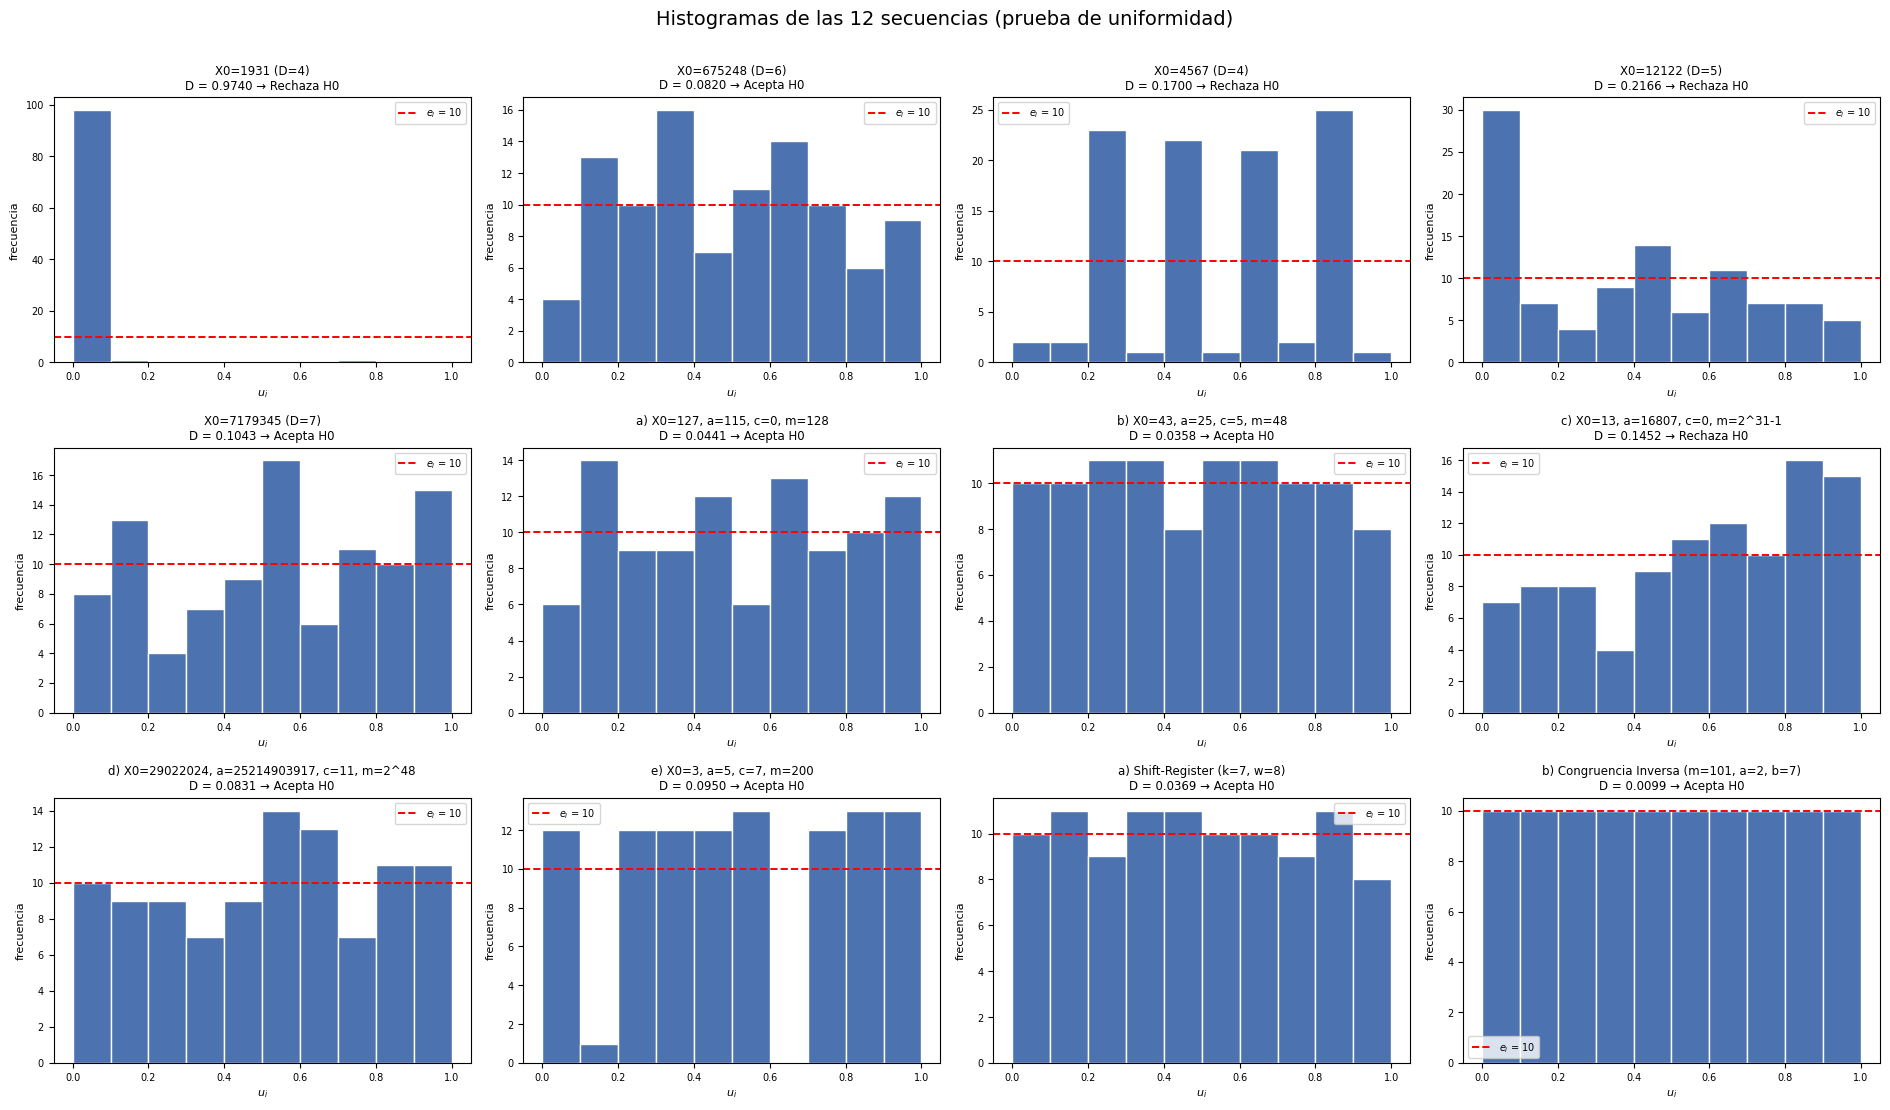

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(19, 11))
for ax, (grupo, etq, U, mu, lam, nota) in zip(axes.ravel(), secuencias):
    ks = ks_uniformidad(U)
    ax.hist(U, bins=10, range=(0, 1), color="#4C72B0", edgecolor="white")
    ax.axhline(N / 10, color="red", ls="--", lw=1.4, label="$e_i$ = 10")
    ax.set_title(f"{etq}\nD = {ks['D']:.4f} → {ks['decision']}", fontsize=8.5)
    ax.set_xlabel("$u_i$", fontsize=8); ax.set_ylabel("frecuencia", fontsize=8)
    ax.tick_params(labelsize=7); ax.legend(fontsize=7)
fig.suptitle("Histogramas de las 12 secuencias (prueba de uniformidad)", fontsize=14, y=1.005)
fig.tight_layout(); plt.show()

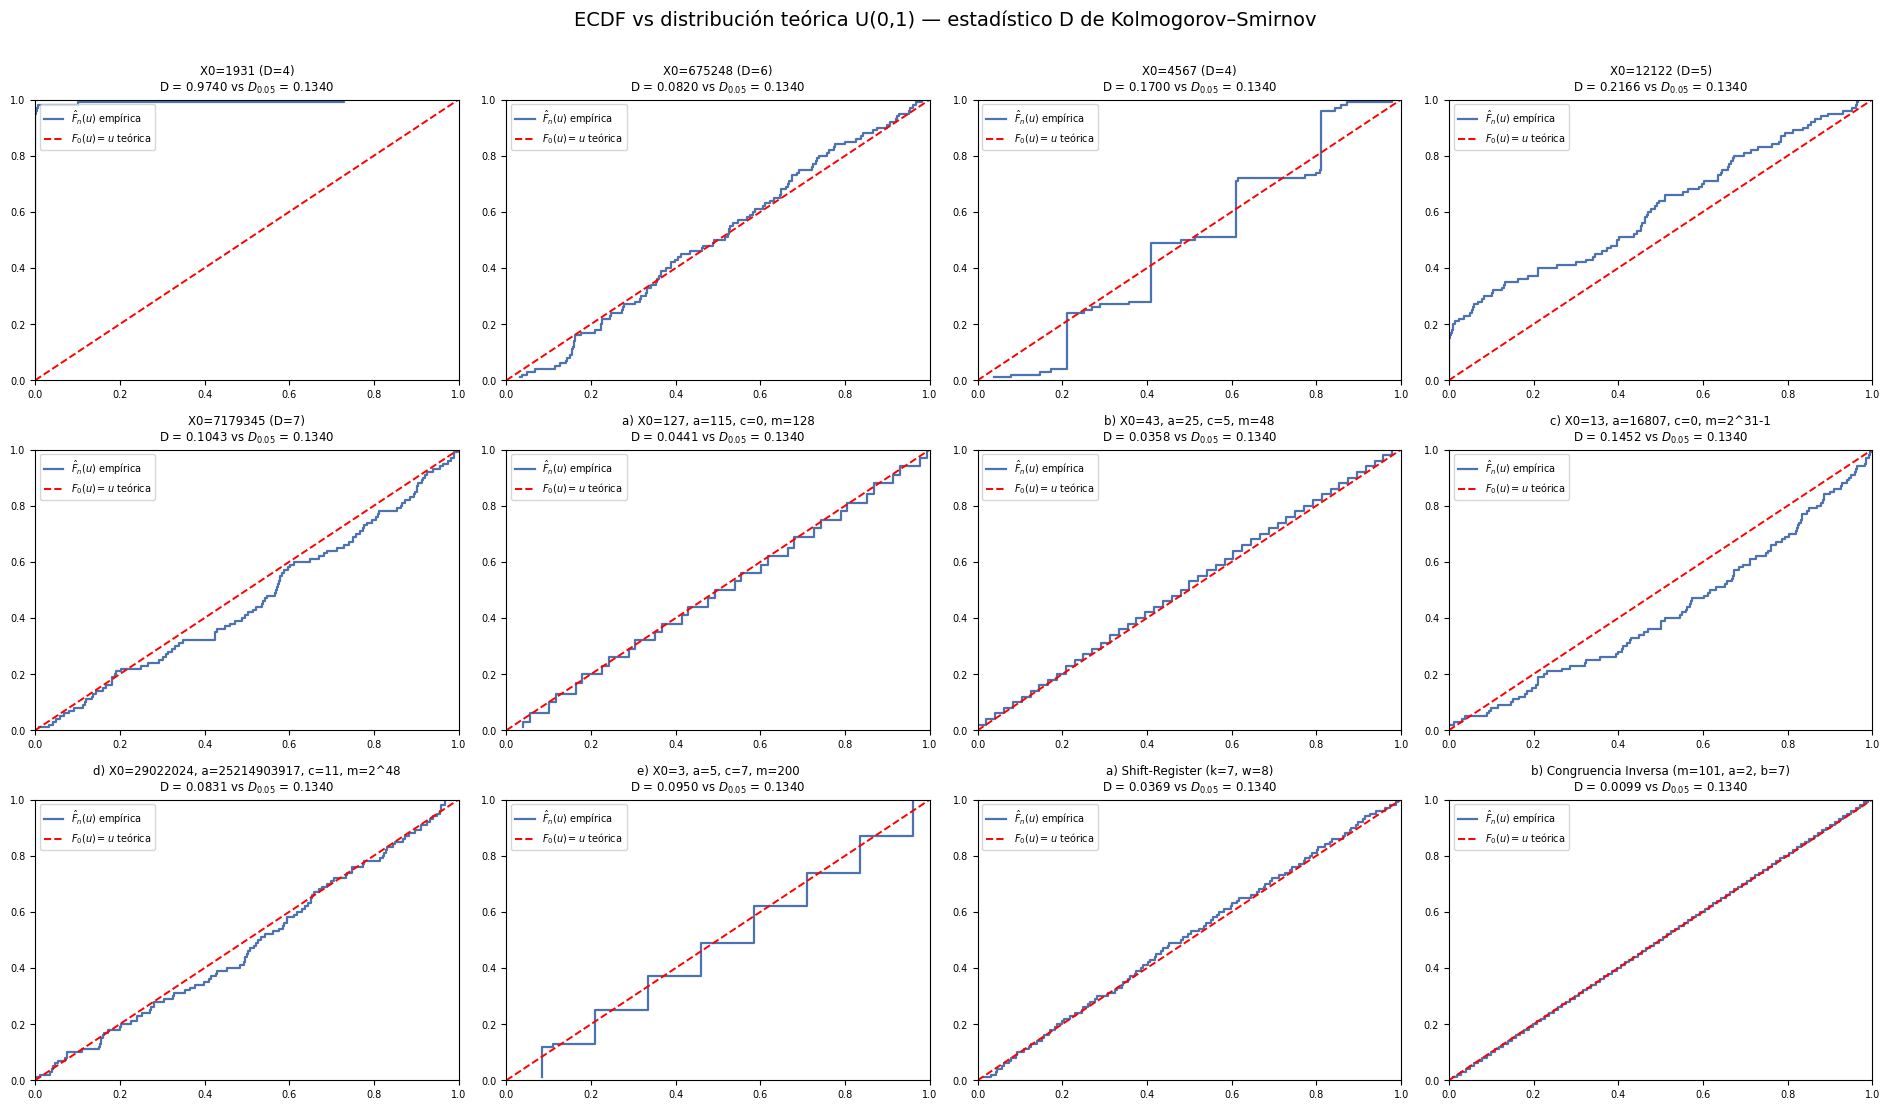

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(19, 11))
for ax, (grupo, etq, U, mu, lam, nota) in zip(axes.ravel(), secuencias):
    ks = ks_uniformidad(U)
    u = np.sort(np.asarray(U, dtype=float))
    ecdf = np.arange(1, len(u) + 1) / len(u)
    ax.step(u, ecdf, where="post", color="#4C72B0", lw=1.6, label="$\\hat F_n(u)$ empírica")
    ax.plot([0, 1], [0, 1], color="red", ls="--", lw=1.4, label="$F_0(u)=u$ teórica")
    ax.set_title(f"{etq}\nD = {ks['D']:.4f} vs $D_{{0.05}}$ = {ks['D_alpha']:.4f}", fontsize=8.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.tick_params(labelsize=7); ax.legend(fontsize=7, loc="upper left")
fig.suptitle("ECDF vs distribución teórica U(0,1) — estadístico D de Kolmogorov–Smirnov",
             fontsize=14, y=1.005)
fig.tight_layout(); plt.show()

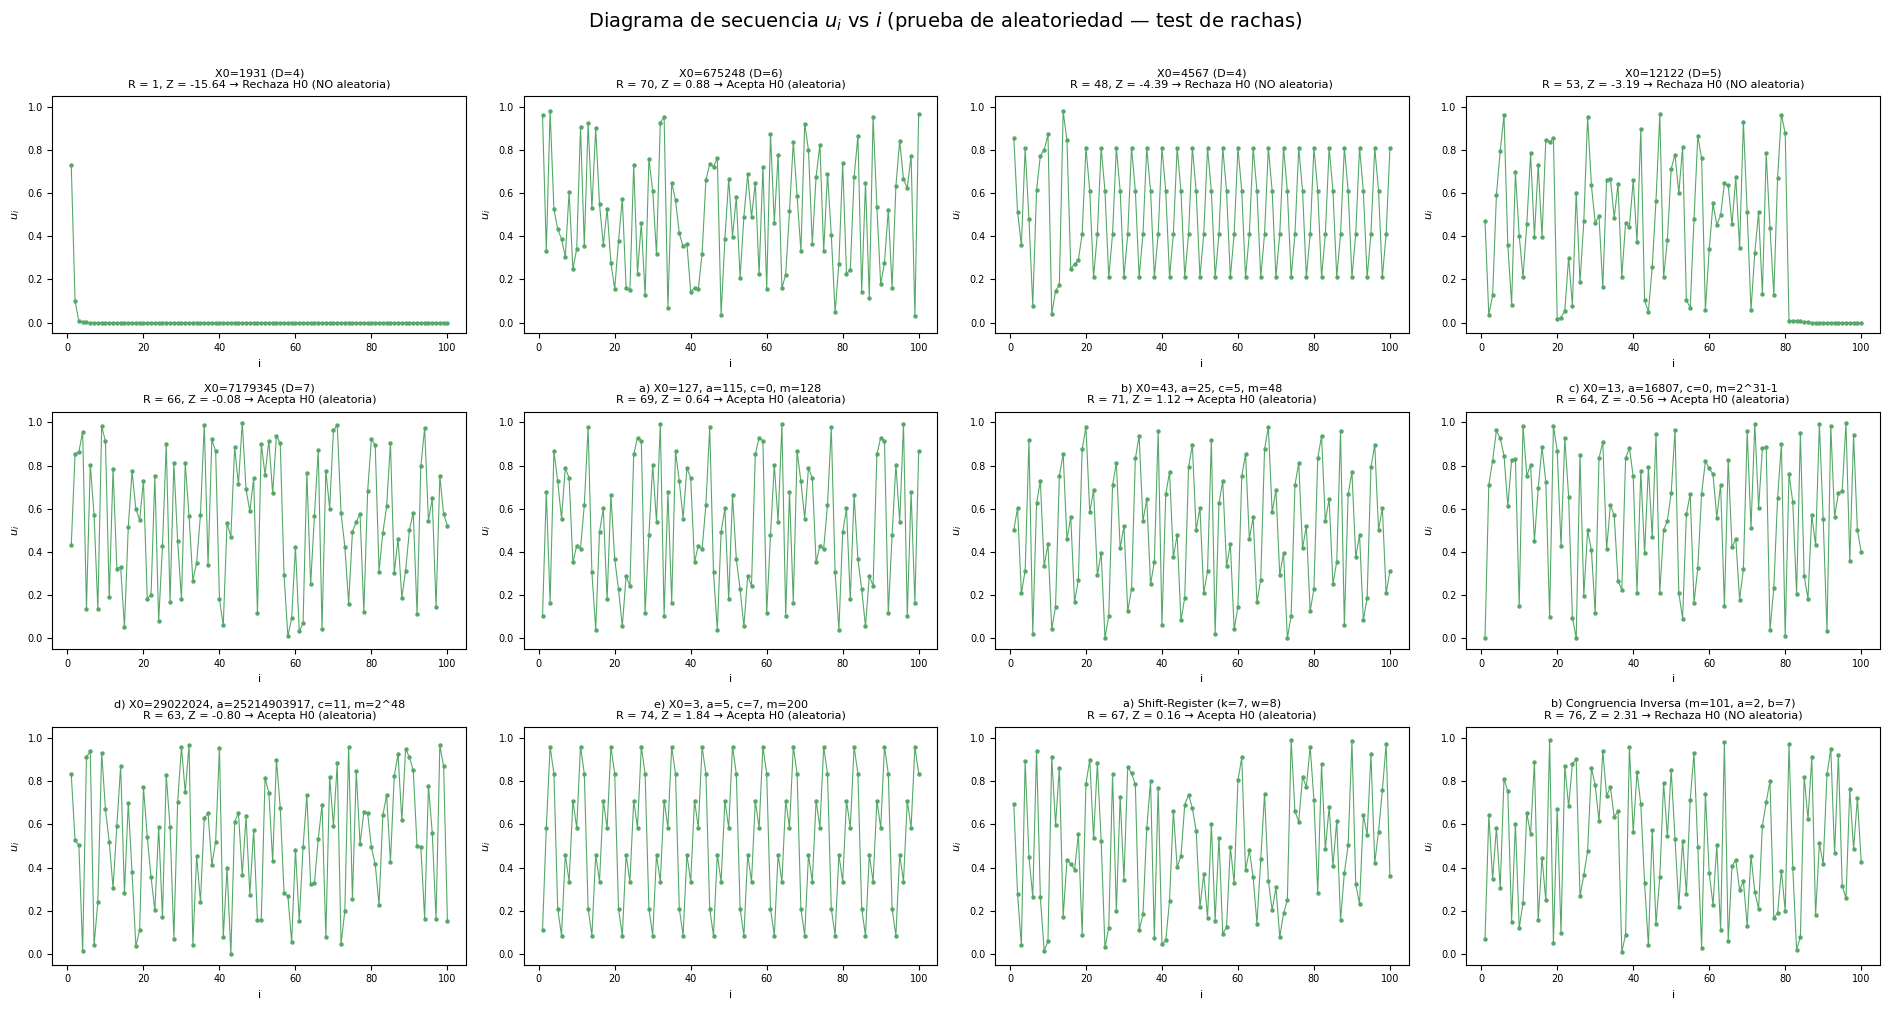

In [19]:
# Diagrama de secuencia: permite ver visualmente tendencia, periodicidad o alternancia
fig, axes = plt.subplots(3, 4, figsize=(19, 10))
for ax, (grupo, etq, U, mu, lam, nota) in zip(axes.ravel(), secuencias):
    ra = test_rachas(U)
    ax.plot(range(1, len(U) + 1), U, marker="o", ms=2.2, lw=0.8, color="#55A868")
    z_txt = "-" if ra["Z"] is None else f"{ra['Z']:.2f}"
    ax.set_title(f"{etq}\nR = {ra['R']}, Z = {z_txt} → {ra['decision']}", fontsize=8)
    ax.set_xlabel("i", fontsize=8); ax.set_ylabel("$u_i$", fontsize=8)
    ax.set_ylim(-0.05, 1.05); ax.tick_params(labelsize=7)
fig.suptitle("Diagrama de secuencia $u_i$ vs $i$ (prueba de aleatoriedad — test de rachas)",
             fontsize=14, y=1.005)
fig.tight_layout(); plt.show()

---

## Respuestas a las preguntas

De acuerdo con el tamaño de ciclo encontrado y las pruebas de uniformidad y aleatoriedad:

### Resumen de lo obtenido

| Punto | Generador | Periodo $\lambda$ | Cola $\mu$ | $D$ (KS) | KS | $\chi^2$ | $Z$ (rachas) | Rachas | Pruebas |
|---|---|---|---|---|---|---|---|---|---|
| 5.1.1 | MidSquare $X_0=1931$ | **1** | 7 | 0.9740 | FALLA | FALLA | −15.64 | FALLA | 0/3 |
| 5.1.1 | MidSquare $X_0=675248$ | **1** | 210 | 0.0820 | PASA | PASA | 0.88 | PASA | 3/3 |
| 5.1.1 | MidSquare $X_0=4567$ | **4** | 19 | 0.1700 | FALLA | FALLA | −4.39 | FALLA | 0/3 |
| 5.1.1 | MidSquare $X_0=12122$ | **1** | 88 | 0.2166 | FALLA | FALLA | −3.19 | FALLA | 0/3 |
| 5.1.1 | MidSquare $X_0=7179345$ | **20** | 848 | 0.1043 | PASA | PASA | −0.08 | PASA | 3/3 |
| 5.1.2 | GLC a) $m=128$ | **32** | 0 | 0.0441 | PASA | PASA | 0.64 | PASA | 3/3 |
| 5.1.2 | GLC b) $m=48$ | **48** | 0 | 0.0358 | PASA | PASA | 1.12 | PASA | 3/3 |
| 5.1.2 | GLC c) $m=2^{31}-1$ | **2 147 483 646** | 0 | 0.1452 | FALLA | PASA | −0.56 | PASA | 2/3 |
| 5.1.2 | GLC d) $m=2^{48}$ | **281 474 976 710 656** | 0 | 0.0831 | PASA | PASA | −0.80 | PASA | 3/3 |
| 5.1.2 | GLC e) $m=200$ | **8** | 2 | 0.0950 | PASA | FALLA | 1.84 | PASA | 2/3 |
| 5.1.3 | Shift-Register | **127** | 0 | 0.0369 | PASA | PASA | 0.16 | PASA | 3/3 |
| 5.1.3 | Congruencia Inversa | **101** | 0 | 0.0099 | PASA | PASA | 2.31 | **FALLA** | 2/3 |

Nótese que la congruencia inversa es el generador **más uniforme** de todos y aun así **falla** el test de rachas ($|Z| = 2.31 > 1.96$).

> **Advertencia metodológica importante:** un generador cuyo periodo es **menor o igual** que el tamaño de
> la muestra ($\lambda \le n = 100$) recorre su ciclo completo dentro de la muestra, de modo que "acierta"
> las pruebas de uniformidad de manera **artificial**: al enumerar todos sus estados una o varias veces
> exactas, produce un histograma perfectamente plano. Por eso el criterio del **tamaño de ciclo debe
> analizarse antes que las pruebas estadísticas**, no después.

---

### ¿Cuáles son los peores generadores de números aleatorios y por qué?

**1. MidSquare con $X_0 = 1931$ — el peor de todos.**
Es el caso más catastrófico. Tras solo 7 iteraciones la secuencia colapsa al estado absorbente
$X_i = 0$ y **el periodo es $\lambda = 1$**: a partir de ahí devuelve $u_i = 0$ indefinidamente
(93 de los 100 valores son exactamente 0). Falla las tres pruebas de forma extrema: $D = 0.9740$ frente a
$D_{0.05} = 0.1340$, $\chi^2 = 860.6$ frente a 16.919, y $Z = -15.64$ con una sola racha. No es un
generador de números aleatorios: es una constante.

**2. MidSquare con $X_0 = 12122$ y $X_0 = 4567$.**
Sufren la misma patología del método de cuadrados medios. El de $X_0 = 12122$ degenera a cero en la
iteración 88 ($\lambda = 1$) y el de $X_0 = 4567$ cae en el ciclo corto
$4100 \to 8100 \to 6100 \to 2100$ de **$\lambda = 4$**, de modo que 82 de los 100 valores son apenas
4 números repetidos. Ambos rechazan las tres pruebas.

**3. Congruencial mixto e) $X_0=3$, $a=5$, $c=7$, $m=200$.**
Su **periodo es de solo $\lambda = 8$**: en 100 números genera únicamente 9 valores distintos. No cumple
las condiciones de Hull–Dobell para periodo completo, porque $m = 200 = 2^3 \cdot 5^2$ es divisible por 5
pero $a - 1 = 4$ no lo es. Aunque los 8 valores del ciclo están repartidos y por eso "pasa" el KS
($D = 0.0950$), el contraste $\chi^2$ lo **rechaza** ($\chi^2 = 22.8 > 16.919$) porque hay clases con
frecuencia 0 y 1 mientras las demás tienen 12 o 13. Es un buen ejemplo de por qué el periodo debe
revisarse siempre: pasar una prueba de uniformidad con periodo 8 no significa nada.

**4. Congruencial mixto a) $m = 128$ y b) $m = 48$ — malos por periodo, no por distribución.**
Pasan las tres pruebas, pero su periodo es $\lambda = 32$ y $\lambda = 48$ respectivamente, es decir,
**menor que la muestra de $n=100$**. Pasan la uniformidad justamente porque recorren su ciclo completo
2 o 3 veces enteras, lo cual produce un histograma plano de forma trivial. El caso a) además usa
$c = 0$ con $m = 2^7$, y al ser multiplicativo con módulo potencia de 2 su periodo máximo posible es
apenas $m/4 = 32$, que es exactamente lo que se obtuvo. Para cualquier simulación real son inservibles:
se repetirían decenas de veces.

**5. Generador de congruencia inversa (con estos parámetros).**
Tiene periodo completo $\lambda = m = 101$ y la mejor uniformidad de todo el laboratorio
($D = 0.0099$, $\chi^2 = 0.00$, con exactamente 10 observaciones en cada una de las 10 clases), pero
**falla el test de rachas** ($R = 76$ frente a los 66.33 esperados, $Z = 2.31 > 1.96$). Ese exceso de
rachas revela un patrón de **alternancia** (zig-zag) entre valores altos y bajos: los números están
perfectamente repartidos pero **no llegan en orden aleatorio**. Es la mejor ilustración del laboratorio
de que uniformidad y aleatoriedad son propiedades distintas e independientes: se puede ser
perfectamente uniforme y aun así no ser aleatorio.

---

### ¿Cuáles son los mejores generadores de números aleatorios y por qué?

**1. Congruencial mixto d) $X_0 = 29022024$, $a = 25214903917$, $c = 11$, $m = 2^{48}$ — el mejor.**
Es el único que combina las tres virtudes:

- **Periodo máximo posible**: $\lambda = m = 2^{48} \approx 2.8 \times 10^{14}$. Cumple las tres
  condiciones de Hull–Dobell: $\gcd(c, m) = \gcd(11, 2^{48}) = 1$; $a - 1 = 25214903916$ es divisible
  por 2, que es el único factor primo de $m$; y como $4 \mid m$, también $4 \mid (a-1)$.
- **Uniformidad**: pasa ambos contrastes con holgura ($D = 0.0831 < 0.1340$, $p = 0.469$;
  $\chi^2 = 4.80 < 16.919$, $p = 0.851$).
- **Aleatoriedad**: pasa el test de rachas cómodamente ($R = 63$, $Z = -0.80$, $p = 0.425$).

Es el generador que usa `java.util.Random` y `drand48()` de C, precisamente por estas propiedades.

**2. Generador Shift-Register (LFSR con $k = 7$, $w = 8$).**
Alcanza el **periodo máximo de su registro**, $\lambda = 2^7 - 1 = 127$ bits (secuencia de longitud
máxima o *m-sequence*), y pasa las tres pruebas con muy buenos márgenes: $D = 0.0369$ ($p = 0.999$),
$\chi^2 = 1.00$ ($p = 0.999$) y $R = 67$ con $Z = 0.16$ ($p = 0.873$), es decir, prácticamente el número
de rachas esperado. Su única limitación es de escala, no de calidad: con $k = 7$ el periodo es corto
para una simulación grande, pero eso se corrige de inmediato aumentando $k$ (con $k = 31$ o $k = 89$ el
periodo pasa a ser astronómico) sin cambiar el algoritmo. Además es muy eficiente, pues solo usa XOR y
desplazamientos.

**3. Congruencial mixto c) $X_0 = 13$, $a = 16807$, $c = 0$, $m = 2^{31}-1$ (MINSTD / Lehmer).**
Su **periodo es $\lambda = m - 1 = 2\,147\,483\,646$**, el máximo alcanzable por un generador
multiplicativo, porque $m$ es el primo de Mersenne $2^{31}-1$ y $a = 16807 = 7^5$ es raíz primitiva
módulo $m$. Pasa el $\chi^2$ ($\chi^2 = 12.0$, $p = 0.213$) y el test de rachas ($Z = -0.56$,
$p = 0.577$). Solo falla el KS de forma **marginal**: $D = 0.1452$ frente a $D_{0.05} = 0.1340$, con
$p = 0.0264$, un rechazo apenas por debajo del umbral $\alpha = 0.05$ que se explica por la variabilidad
propia de una muestra de apenas $n = 100$ y no por un defecto estructural del generador (con $\alpha=0.01$,
$D_{0.01} = 0.1607$, se aceptaría). Es un generador clásico y ampliamente validado.

**4. MidSquare con $X_0 = 7179345$ y $X_0 = 675248$ — buenos solo por suerte.**
Pasan las tres pruebas dentro de la ventana de $n = 100$ ($D = 0.1043$ y $D = 0.0820$; $Z = -0.08$ y
$Z = 0.88$), pero **no son recomendables**: al seguir la secuencia más allá de los 100 valores se
comprueba que el de $X_0 = 7179345$ cae en un ciclo de $\lambda = 20$ después de 848 iteraciones, y el
de $X_0 = 675248$ **degenera a cero** en la iteración 210 ($\lambda = 1$). Es decir, los buenos
resultados se deben únicamente a que la muestra se cortó antes de que apareciera la patología. Esto
confirma el defecto de fondo del método de cuadrados medios: su comportamiento depende críticamente de
la semilla, no ofrece ninguna garantía teórica sobre el periodo, y siempre termina degenerando.

---

### Conclusión general

**Ranking final:** GLC $m=2^{48}$ > Shift-Register > GLC $m=2^{31}-1$ > Congruencia inversa >
GLC $m=48$ > GLC $m=128$ > MidSquare (7179345, 675248) > GLC $m=200$ > MidSquare (4567, 12122, 1931).

Las conclusiones del laboratorio son tres:

1. **El tamaño de ciclo es el criterio previo y decisivo.** Un generador con periodo pequeño puede pasar
   las pruebas estadísticas de forma engañosa (casos $m=128$, $m=48$), porque recorrer el ciclo completo
   produce un histograma perfectamente plano. Un buen generador debe tener un periodo mucho mayor que la
   cantidad de números que se van a consumir en la simulación.

2. **Uniformidad y aleatoriedad son propiedades independientes y hay que probar ambas.** El generador de
   congruencia inversa es el más uniforme de todos ($\chi^2 = 0.00$) y aun así no es aleatorio
   ($Z = 2.31$): sus valores están perfectamente repartidos pero llegan alternando alto-bajo. Una sola
   prueba nunca es suficiente.

3. **El método de cuadrados medios (MidSquare) debe descartarse en la práctica.** De sus cinco semillas,
   tres fallaron las tres pruebas y las dos que las pasaron degeneran igualmente si se extiende la
   secuencia. No tiene garantía teórica de periodo y siempre acaba en ciclos cortos o en el estado
   absorbente cero. Los generadores congruenciales lineales con parámetros que cumplen Hull–Dobell (o
   raíz primitiva en el caso multiplicativo) y los de registro de desplazamiento son las opciones
   correctas.